In [7]:
# 1) 한 번만: 압축 풀기
!tar xzf sample_data/EnglishFnt.tgz -C sample_data/

In [8]:
# ────────────────────────────────────────────────────────────────
# 0) EnglishFnt에서 D/N/E 데이터셋 자동 구축
# ────────────────────────────────────────────────────────────────
import os
from pathlib import Path
from PIL import Image
import shutil
import random

# 원본 폰트 이미지 경로
FNT_BASE = Path("sample_data/English/Fnt")
OUT_BASE = Path("dataset")
CLASS_MAP = {'Sample014': 'D', 'Sample024': 'N', 'Sample015': 'E'}

# dataset/D, dataset/N, dataset/E 폴더 생성 및 초기화
for c in ['D', 'N', 'E']:
    d = OUT_BASE / c
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# 클래스별로 파일 복사 (최대 2000장씩 샘플)
for sample, label in CLASS_MAP.items():
    src = FNT_BASE / sample
    dst = OUT_BASE / label
    files = list(src.glob("*.png"))
    random.shuffle(files)
    for i, f in enumerate(files[:2000]):
        img = Image.open(f).convert("L").resize((32,32))
        img.save(dst / f"{label}_{i:04d}.png")

print("EnglishFnt → dataset/D,N,E 자동 구축 완료")

# ────────────────────────────────────────────────────────────────
# 1) Keras 데이터셋 로드 및 증강
# ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE    = (32, 32)
BATCH_SIZE  = 64
EPOCHS      = 30
TFLITE_PATH = "dne_classifier.tflite"
CLASS_NAMES = ["D", "N", "E"]
VALID_SPLIT = 0.2
SEED        = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="validation",
    seed=SEED
)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.3),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
])


def preprocess_train(x, y):
    x = tf.expand_dims(x, -1) if x.shape[-1] != 1 else x
    x = data_augmentation(x)
    x = normalization(x)
    return x, y

train_ds = train_ds.map(preprocess_train).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────
# 2) CNN 모델 정의 및 학습
# ────────────────────────────────────────────────────────────────
def build_dne_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dne_model(IMG_SIZE + (1,), len(CLASS_NAMES))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ────────────────────────────────────────────────────────────────
# 3) TFLite 변환 및 저장
# ────────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print(f"3-class TFLite model saved at '{TFLITE_PATH}'")


EnglishFnt → dataset/D,N,E 자동 구축 완료
Found 3048 files belonging to 3 classes.
Using 2439 files for training.
Found 3048 files belonging to 3 classes.
Using 609 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 157,027 (613.39 KB)

 Trainable params: 156,387 (610.89 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 521ms/step - accuracy: 0.4592 - loss: 1.0318 - val_accuracy: 0.3383 - val_loss: 1.1283
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - accuracy: 0.7172 - loss: 0.7323 - val_accuracy: 0.3383 - val_loss: 1.5953
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.8104 - loss: 0.5003 - val_accuracy: 0.3383 - val_loss: 1.2240
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 478ms/step - accuracy: 0.8682 - loss: 0.3707 - val_accuracy: 0.4959 - val_loss: 0.9533
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 511ms/step - accuracy: 0.8876 - loss: 0.3079 - val_accuracy: 0.6338 - val_loss: 0.7558
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 513ms/step - accuracy: 0.9171 - loss: 0.2450 - val_accuracy: 0.9064 - val_loss: 0.3543
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 496ms/step - accuracy: 0.9283 - loss: 0.2026 - val_accuracy: 0.6207 - val_loss: 0.7765
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 490ms/step - accuracy: 0.9191 - loss: 0.2225 - val_accu

In [9]:
# ─────────────────────────────
# 0. 패키지 임포트 및 설정
# ─────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import tensorflow as tf

# 사용자 설정
IMAGE_PATH   = "/content/test2.png"       # 근무표 이미지 경로
TFLITE_MODEL = "dne_classifier.tflite"      # TFLite 분류기 모델
WHITE_THRESH = 0.92                       # 빈 셀 판단 기준
CLASS_LABELS = ['D', 'N', 'E']              # 분류 클래스
HEADER_SKIP_Y = 1                           # 위쪽 헤더 행 수
HEADER_SKIP_X = 1                           # 왼쪽 헤더 열 수
# 회전 재시도 트리거 범위 (max_prob)
LOW_CONF_MIN = 0.2
LOW_CONF_MAX = 0.4

# ─────────────────────────────
# 1. 표 검출 및 워핑(정렬)
# ─────────────────────────────
def detect_and_warp_table(img_path):
    orig_img = cv2.imread(img_path)
    assert orig_img is not None, f"Image not found at {img_path}"
    max_width = 1000
    if orig_img.shape[1] > max_width:
        scale = max_width / orig_img.shape[1]
        orig_img = cv2.resize(orig_img, None, fx=scale, fy=scale)
    gray = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 8)
    plt.imshow(binary, cmap='gray')
    plt.title("이진화된 이미지")
    plt.axis('off')
    plt.show()

    # 외곽 검출
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    table_contour = None
    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        if len(approx) == 4:
            table_contour = approx
            break

    if table_contour is not None:
        def sort_points(pts):
            pts = pts.reshape(4, 2)
            s = pts.sum(axis=1)
            diff = np.diff(pts, axis=1)
            return np.array([
                pts[np.argmin(s)], pts[np.argmin(diff)],
                pts[np.argmax(s)], pts[np.argmax(diff)]
            ], dtype='float32')
        rect = sort_points(table_contour)
        width = int(max(np.linalg.norm(rect[0] - rect[1]), np.linalg.norm(rect[2] - rect[3])))
        height = int(max(np.linalg.norm(rect[0] - rect[3]), np.linalg.norm(rect[1] - rect[2])))
        dst = np.array([[0,0],[width-1,0],[width-1,height-1],[0,height-1]], dtype='float32')
        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(orig_img, M, (width, height))
        # 시각화
        temp = orig_img.copy()
        cv2.drawContours(temp, [table_contour], -1, (0, 255, 0), 3)
    else:
        print("⚠️ 표 외곽 인식 실패 — 원본 사용")
        warped = orig_img
        temp = orig_img.copy()

    #회전
    h, w = warped.shape[:2]
    if h > w:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

    temp_rgb = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
    plt.imshow(temp_rgb)
    plt.title("표 외곽 검출 결과")
    plt.axis('off')
    plt.show()
    return warped

# 셀 비정상일 때 전처리 함수
def enhanced_preprocess_for_grid(
    orig_img,
    target_height=600,          # 더 크게 키워서 얇은 선 보존
    clahe_clip=3.0,             # 대비 강화 ↑
    clahe_tile=(8, 8),
    thr_block_mean=15,          # 작은 블록 → 세밀 검출
    thr_C_mean=8,
    thr_block_gauss=17,         # 가우시안도 병행
    thr_C_gauss=10,
    dilate_iter=1,              # 팽창 반복 횟수
    show=False
):
    print("reprocces")
    # 1) 업스케일
    h, w = orig_img.shape[:2]
    scale = float(target_height) / max(1, h)
    resized = cv2.resize(orig_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # 2) Gray + 언샤프 마스크
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
    sharp = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    # 3) CLAHE
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    gray_c = clahe.apply(sharp)

    # 4) 흰 배경, 검은 글자 이진화 (INVERT 제거)
    bw_mean = cv2.adaptiveThreshold(
        gray_c, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,
        thr_block_mean, thr_C_mean
    )
    bw_gaus = cv2.adaptiveThreshold(
        gray_c, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        thr_block_gauss, thr_C_gauss
    )
    bw = cv2.bitwise_and(bw_mean, bw_gaus)  # OR → AND로 하면 더 깔끔한 글자 가능

    # 5) 작은 점 제거
    bw = cv2.medianBlur(bw, 3)

    # 6) 팽창 (얇은 선 진하게)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    bw_thick = cv2.dilate(bw, kernel, iterations=dilate_iter)

    # 7) 구멍 메우기
    bw_strong = cv2.morphologyEx(
        bw_thick, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)), iterations=1
    )

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
    plt.title("resized original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(bw_strong, cmap='gray')
    plt.title("processed result")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


    return bw_strong, gray_c, resized


def get_table_cells(
    warped,
    bin_for_lines=None,
    skip_rows=HEADER_SKIP_Y,
    skip_cols=HEADER_SKIP_X,
    header_pos="top-left",
    try_polarity=True,
    show_grid=False,
    retry_src=None,
):
    img  = warped
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img.copy()

    def suppress_text_and_extract_lines(binary):

        h, w = binary.shape
        num, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        text_mask = np.zeros_like(binary)
        area_max = int(0.01 * w * h)
        for i in range(1, num):
            x, y, ww, hh, area = stats[i]
            if area < 10:
                continue
            ar = ww / (hh + 1e-6)
            if area <= area_max and 0.2 <= ar <= 5.0:
                text_mask[y:y+hh, x:x+ww] = 255
        no_text = cv2.bitwise_and(binary, cv2.bitwise_not(text_mask))

        hor_k = cv2.getStructuringElement(cv2.MORPH_RECT, (max(20, w//18), 1))
        ver_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(20, h//6)))
        hor_only = cv2.morphologyEx(no_text, cv2.MORPH_OPEN, hor_k, iterations=1)
        ver_only = cv2.morphologyEx(no_text, cv2.MORPH_OPEN, ver_k, iterations=1)

        hor_only = cv2.dilate(hor_only, cv2.getStructuringElement(cv2.MORPH_RECT, (3,1)), 1)
        ver_only = cv2.dilate(ver_only, cv2.getStructuringElement(cv2.MORPH_RECT, (1,3)), 1)

        row_len = (hor_only > 0).sum(axis=1)
        col_len = (ver_only > 0).sum(axis=0)
        row_min = int(0.55 * w)
        col_min = int(0.55 * h)
        y_idxs = np.where(row_len >= row_min)[0].tolist()
        x_idxs = np.where(col_len >= col_min)[0].tolist()

        def group(coords, tol=12):
            if not coords: return []
            coords = sorted(coords)
            out, cur = [], [coords[0]]
            for c in coords[1:]:
                if c - cur[-1] <= tol: cur.append(c)
                else: out.append(int(np.mean(cur))); cur = [c]
            out.append(int(np.mean(cur)))
            return out

        y_lines = group(y_idxs)
        x_lines = group(x_idxs)
        grid = cv2.bitwise_or(hor_only, ver_only)
        return y_lines, x_lines, grid

    def build_ranges(ys, xs):
        return ([(ys[i], ys[i+1]) for i in range(len(ys)-1)],
                [(xs[j], xs[j+1]) for j in range(len(xs)-1)])

    # 1) 이진 입력 준비 (없으면 내부에서 생성: 선=흰색이 되도록 INV)
    if bin_for_lines is None:
        bw = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 21, 10)
    else:
        bw = bin_for_lines.copy()

    y_lines, x_lines, _ = suppress_text_and_extract_lines(bw)
    if try_polarity and (len(y_lines) < 3 or len(x_lines) < 3):
        y_lines, x_lines, _ = suppress_text_and_extract_lines(255 - bw)

    row_ranges, col_ranges = build_ranges(y_lines, x_lines)
    cells_num = (len(y_lines) - 1) * (len(x_lines) - 1)

    # 시각화 베이스(기본: warped의 gray 크기와 일치하는 BGR)
    vis_img_base = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    if cells_num < 100 or cells_num > 200:
        print("셀 개수 비정상, 전처리 결과 기반 재검출 시도")
        src = retry_src if retry_src is not None else img
        bw2, _, resized2 = enhanced_preprocess_for_grid(src, target_height=600, show=False)
        bw_retry = 255 - bw2  # 선=흰색 유지
        y2, x2, _ = suppress_text_and_extract_lines(bw_retry)

         # 재검출 결과가 더 타당하면 교체
        if len(y2) >= 3 and len(x2) >= 3:
            y_lines, x_lines = y2, x2
            row_ranges, col_ranges = build_ranges(y_lines, x_lines)
            vis_img_base = resized2  # 크기 정합
            print(f"[RETRY] y_lines={len(y_lines)}, x_lines={len(x_lines)}, "
                  f"cells={(len(y_lines)-1)*(len(x_lines)-1)}")
        else:
            print("[RETRY] 실패: 충분한 라인을 찾지 못함 (기존 결과 유지)")

    draw = vis_img_base.copy()
    H, W = draw.shape[:2]
    for y in y_lines: cv2.line(draw, (0, y), (W-1, y), (0, 0, 255), 2)
    for x in x_lines: cv2.line(draw, (x, 0), (x, H-1), (0, 0, 255), 2)
    plt.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
    plt.title("grid 검출 결과"); plt.axis('off'); plt.show()

    return cv2.cvtColor(vis_img_base, cv2.COLOR_BGR2GRAY), row_ranges, col_ranges




In [10]:
from google.colab.patches import cv2_imshow

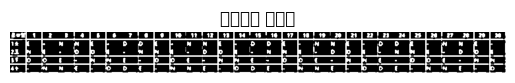

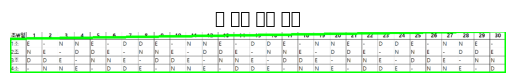

셀 개수 비정상, 전처리 결과 기반 재검출 시도
reprocces


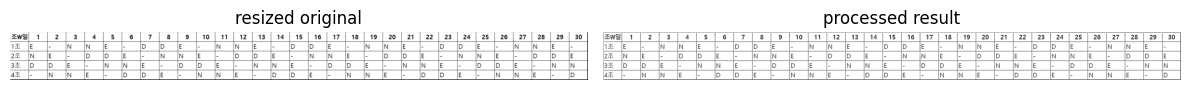

[RETRY] y_lines=5, x_lines=32, cells=124


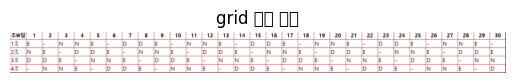

[1] 원본 + bbox


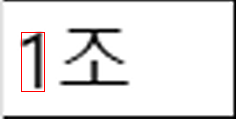

→ 잘린 셀:


[2] 원본 + bbox


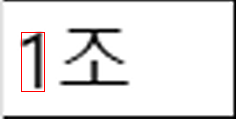

→ 잘린 셀:


[r0 c0]Probabilities: D=0.873, N=0.044, E=0.083 (max=0.873)
[3] 원본 + bbox


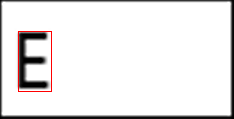

→ 잘린 셀:


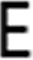

[4] 원본 + bbox


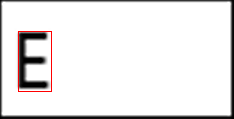

→ 잘린 셀:


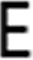

[r0 c1]Probabilities: D=0.010, N=0.006, E=0.984 (max=0.984)
[5] 원본 + bbox


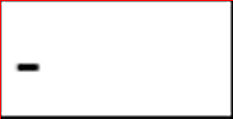

→ 잘린 셀:


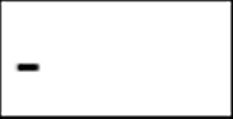

[r0 c2] blank by white_ratio=0.932
[r0 c3]Probabilities: D=0.676, N=0.318, E=0.006 (max=0.676)
[r0 c4]Probabilities: D=0.677, N=0.321, E=0.002 (max=0.677)
[r0 c5]Probabilities: D=0.010, N=0.006, E=0.984 (max=0.984)
[r0 c6]Probabilities: D=0.006, N=0.717, E=0.277 (max=0.717)
[r0 c7]Probabilities: D=1.000, N=0.000, E=0.000 (max=1.000)
[r0 c8]Probabilities: D=1.000, N=0.000, E=0.000 (max=1.000)
[r0 c9]Probabilities: D=0.008, N=0.004, E=0.988 (max=0.988)
[r0 c10]Probabilities: D=0.006, N=0.715, E=0.280 (max=0.715)
[r0 c11]Probabilities: D=0.676, N=0.322, E=0.002 (max=0.676)
[r0 c12]Probabilities: D=0.676, N=0.321, E=0.002 (max=0.676)
[r0 c13]Probabilities: D=0.009, N=0.004, E=0.987 (max=0.987)
[r0 c14]Probabilities: D=0.005, N=0.737, E=0.257 (max=0.737)
[r0 c15]Probabilities: D=1.000, N=0.000, E=0.000 (max=1.000)
[r0 c16]Probabilities: D=1.000, N=0.000, E=0.000 (max=1.000)
[r0 c17]Probabilities: D=0.011, N=0.004, E=0.984 (max=0.984)
[r0 c18]Probabilities: D=0.005, N=0.732, E=0.262 (max=0.7

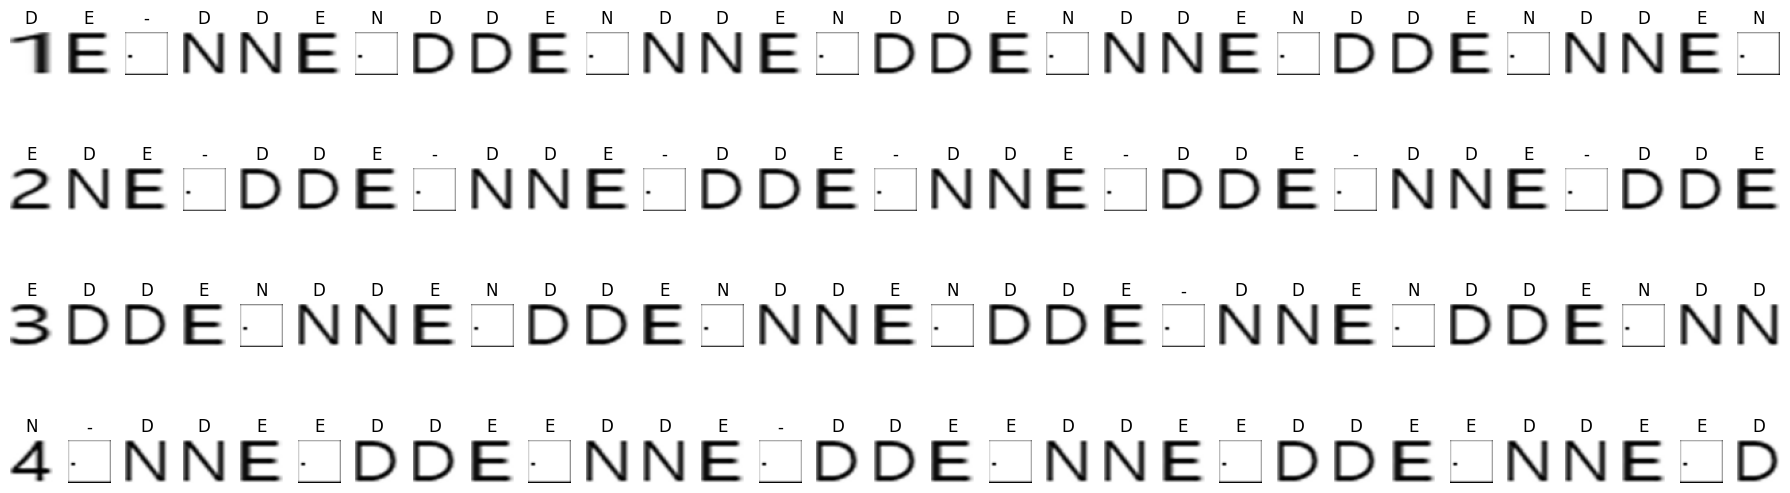

✅ schedule_inferred4.json 저장 완료
{
  "1": {
    "1": "D",
    "2": "E",
    "3": "-",
    "4": "D",
    "5": "D",
    "6": "E",
    "7": "N",
    "8": "D",
    "9": "D",
    "10": "E",
    "11": "N",
    "12": "D",
    "13": "D",
    "14": "E",
    "15": "N",
    "16": "D",
    "17": "D",
    "18": "E",
    "19": "N",
    "20": "D",
    "21": "D",
    "22": "E",
    "23": "N",
    "24": "D",
    "25": "D",
    "26": "E",
    "27": "N",
    "28": "D",
    "29": "D",
    "30": "E",
    "31": "N"
  },
  "2": {
    "1": "E",
    "2": "D",
    "3": "E",
    "4": "-",
    "5": "D",
    "6": "D",
    "7": "E",
    "8": "-",
    "9": "D",
    "10": "D",
    "11": "E",
    "12": "-",
    "13": "D",
    "14": "D",
    "15": "E",
    "16": "-",
    "17": "D",
    "18": "D",
    "19": "E",
    "20": "-",
    "21": "D",
    "22": "D",
    "23": "E",
    "24": "-",
    "25": "D",
    "26": "D",
    "27": "E",
    "28": "-",
    "29": "D",
    "30": "D",
    "31": "E"
  },
  "3": {
    "1": "E",
    "

In [12]:

# ─────────────────────────────
# 3. tight crop + OCR 분류 함수(기존과 동일)
# ─────────────────────────────
def tight_crop_and_resize(cell_img,
                          out_size=(32, 32),
                          pad=2,
                          min_area_frac=0.002,
                          min_h_for_text=6,
                          dash_len_frac=0.18,
                          return_info=False):
    """
    글자(E/N/D)만 타이트 크롭하고, 대시(-)만 있거나 공백이면 원본 유지.
    - 텍스트/대시 마스크 분리 → 컨투어 분류(AR, 높이 기준)
    - 대시 우선 규칙: 대시가 있고 '진짜 글자'가 없으면 크롭 금지
    """
    if cell_img is None or getattr(cell_img, "size", 0) == 0:
        return (np.full(out_size, 255, np.uint8), {"bbox": (0,0,0,0), "had_text": False, "had_dash": False}) \
               if return_info else np.full(out_size, 255, np.uint8)

    h, w = cell_img.shape[:2]

    # ── 0) 전경 마스크 (검정=전경)
    fg_base = (cell_img < 128).astype(np.uint8) * 255

    # ── 1) 프레임 제거
    border = max(2, min(h, w) // 40)
    fg_base[:border, :] = 0; fg_base[-border:, :] = 0
    fg_base[:, :border] = 0; fg_base[:, -border:] = 0

    # ── 2) 텍스트/대시 마스크 분리
    fg_text = cv2.morphologyEx(fg_base, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))          # 텍스트용(가로 팽창 X)
    kx = max(3, w // 30)
    fg_dash = cv2.dilate(fg_base, np.ones((1, kx), np.uint8), 1)                             # 대시용(가로 팽창 O)
    fg_dash = cv2.morphologyEx(fg_dash, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))
    fg_dash_only = cv2.bitwise_and(fg_dash, cv2.bitwise_not(fg_text))                        # 텍스트 영역 제거

    # ── 3) 컨투어
    cnts_text = cv2.findContours(fg_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]
    cnts_dash = cv2.findContours(fg_dash_only, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    area_thr = h * w * min_area_frac
    text_boxes, dash_boxes = [], []

    # ---- 텍스트 후보(AR 제한 포함)
    for c in cnts_text:
        x, y, cw, ch = cv2.boundingRect(c)
        area = cw * ch
        if area > 0.85 * h * w:
            continue
        if (x <= 1 or y <= 1 or x+cw >= w-1 or y+ch >= h-1) and (cw >= 0.9*w or ch >= 0.9*h):
            continue
        ar = cw / max(1, ch)
        is_texty = (area >= area_thr) and (ch >= min_h_for_text) and (ar <= 4.0)  # 길쭉하면 제외
        if is_texty:
            text_boxes.append((x, y, x+cw, y+ch))

    # ---- 대시 후보(AR 크고, 높이 낮음)
    dash_ar_min = 5.0
    dash_h_max  = max(6, int(0.4 * h))
    for c in cnts_dash:
        x, y, cw, ch = cv2.boundingRect(c)
        area = cw * ch
        if area > 0.85 * h * w:
            continue
        if (x <= 1 or y <= 1 or x+cw >= w-1 or y+ch >= h-1) and (cw >= 0.9*w or ch >= 0.9*h):
            continue
        ar = cw / max(1, ch)
        is_dash = (ar >= dash_ar_min) and (ch <= dash_h_max) and (cw >= int(w * dash_len_frac))
        if is_dash:
            dash_boxes.append((x, y, x+cw, y+ch))

    # ---- 텍스트 박스가 사실상 대시인지 재검사(보수적)
    def _all_boxes_look_like_dash(boxes, H):
        if not boxes:
            return False
        cnt = 0
        for (x1, y1, x2, y2) in boxes:
            cw, ch = x2 - x1, y2 - y1
            ar2 = cw / max(1, ch)
            if ar2 >= 5.0 and ch <= max(6, int(0.4 * H)):
                cnt += 1
        return cnt == len(boxes)

    if text_boxes and _all_boxes_look_like_dash(text_boxes, h):
        dash_boxes.extend(text_boxes)
        text_boxes = []

    # ---- 대시 우선 규칙: 대시가 있고 '진짜 글자'가 없으면 → 대시만 → 크롭 금지
    def _looks_like_text(box, H):
        x1, y1, x2, y2 = box
        cw, ch = x2 - x1, y2 - y1
        ar = cw / max(1, ch)
        return (ch >= int(0.35 * H)) and (ar <= 2.5)

    real_text = [b for b in text_boxes if _looks_like_text(b, h)]
    if dash_boxes and not real_text:
        text_boxes = []           # 대시-only로 간주(크롭 금지)
    else:
        text_boxes = real_text

    # ── 4) 크롭 분기
    if text_boxes:
        xs1, ys1, xs2, ys2 = zip(*text_boxes)
        x1, y1 = max(0, min(xs1) - pad), max(0, min(ys1) - pad)
        x2, y2 = min(w, max(xs2) + pad), min(h, max(ys2) + pad)
        if (x2 - x1) < 4: x1, x2 = max(0, x1 - 2), min(w, x2 + 2)
        if (y2 - y1) < 4: y1, y2 = max(0, y1 - 2), min(h, y2 + 2)
        cropped = cell_img[y1:y2, x1:x2]
        had_text, had_dash = True, bool(dash_boxes)
    else:
        # 글자 없음(= 대시만 or 공백) → 원본 유지
        cropped = cell_img
        x1, y1, x2, y2 = 0, 0, w, h
        had_text, had_dash = False, bool(dash_boxes)

    resized = cv2.resize(cropped, out_size, interpolation=cv2.INTER_AREA)

    # (옵션) 처음 5개만 시각화
    if not hasattr(tight_crop_and_resize, "shown_count"):
        tight_crop_and_resize.shown_count = 0
    if tight_crop_and_resize.shown_count < 5:
        vis = cv2.cvtColor(cell_img, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 1)
        print(f"[{tight_crop_and_resize.shown_count + 1}] 원본 + bbox")
        cv2_imshow(vis)
        print("→ 잘린 셀:"); cv2_imshow(cropped)
        tight_crop_and_resize.shown_count += 1

    if return_info:
        return resized, {"bbox": (x1, y1, x2, y2),
                         "had_text": had_text, "had_dash": had_dash}
    return resized


def classify_dne(cell_img, interpreter, input_details, output_details, debug=False, r=0, c=0):
    tight_img, info = tight_crop_and_resize(cell_img, return_info=True)

    # 완전 공백 체크(크롭 결과 기준)
    white_ratio = np.mean(tight_img > 180)
    if white_ratio > WHITE_THRESH:
        if debug: print(f"[r{r} c{c}] blank by white_ratio={white_ratio:.3f}")
        return '-', 1.0, True

    # 글자 없음 + 대시만 있으면 모델 스킵
    if not info["had_text"] and info["had_dash"]:
        if debug: print(f"[r{r} c{c}] dash-only → skip model")
        return '-', 1.0, True

    # 3) TFLite 추론
    h, w = input_details[0]['shape'][1:3]
    inp = tight_img.astype(np.float32) / 255.0
    sample = inp.reshape(1, h, w, 1)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])[0]
    max_prob = float(np.max(out))

    if debug:
        print(f"[r{r} c{c}]Probabilities: D={out[0]:.3f}, N={out[1]:.3f}, E={out[2]:.3f} (max={max_prob:.3f})")

    # 저신뢰는 공백 취급
    if max_prob < 0.5:
        if debug: print("Blank cell detected by prob:", max_prob)
        return '-', max_prob, True

    label = CLASS_LABELS[int(np.argmax(out))]
    return label, max_prob, False
# ─────────────────────────────
# 새로 추가: 1패스(그리드 추출 + 분류) 실행을 함수로 분리
# ─────────────────────────────
# ===== 자동 스킵 기준(blank 기반) =====
DROP_COL0_BLANK_FRAC = 0.60   # 1열 blank 비율 ≥ 이 값 → 열 삭제
DROP_ROW0_BLANK_FRAC = 0.80   # 1행 blank 비율 ≥ 이 값 → 행 삭제
PROB_THR = 0.80               # (옵션) 확률 보조 기준 유지하고 싶으면 사용

def run_pass(
    warped,
    interpreter,
    input_details,
    output_details,
    show_cells=True,
    pre_grid=None,            # ← (row_ranges, col_ranges) 필수
    gray_override=None,
    show_original=False,
):
    # 0) 그리드 주입 강제
    if pre_grid is None:
        raise ValueError("run_pass에는 pre_grid=(row_ranges, col_ranges)가 필요합니다. "
                         "먼저 get_table_cells()를 호출해 주세요.")

    row_ranges, col_ranges = pre_grid
    # 좌표계 일치용 gray (없으면 warped에서 생성)
    gray = gray_override if gray_override is not None \
           else (cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
                 if warped.ndim == 3 else warped.copy())

    n_rows, n_cols = len(row_ranges), len(col_ranges)
    probs  = np.zeros((n_rows, n_cols), dtype=np.float32)
    labels = [['' for _ in range(n_cols)] for _ in range(n_rows)]
    blanks = np.zeros((n_rows, n_cols), dtype=bool)
    crops  = [[None for _ in range(n_cols)] for _ in range(n_rows)]

    low_conf_count = 0
    debug_count = 0
    result = {}

    if show_cells:
        fig_w = min(max(n_cols * 1.1, 6), 18)
        fig_h = min(max(n_rows * 1.1, 6), 18)
        plt.figure(figsize=(fig_w, fig_h))

    # 2) 전 셀 분류 + 결과 저장
    for r, (y1, y2) in enumerate(row_ranges):
        for c, (x1, x2) in enumerate(col_ranges):
            cell_img = gray[y1:y2, x1:x2]

            tight_img, info = tight_crop_and_resize(cell_img, return_info=True)
            crops[r][c] = tight_img
            has_text, has_dash = info["had_text"], info["had_dash"]

            debug = (debug_count < 50)
            if not has_text and has_dash:
              label, max_prob, is_blank = '-', 1.0, True
            else:
                label, max_prob, is_blank = classify_dne(
                    cell_img, interpreter, input_details, output_details,
                    debug=debug, r=r, c=c
                )
            labels[r][c] = label
            probs[r, c]  = max_prob
            blanks[r, c] = is_blank

            if LOW_CONF_MIN <= max_prob <= LOW_CONF_MAX:
                low_conf_count += 1
            if debug: debug_count += 1

            if show_cells:
                ax = plt.subplot(n_rows, n_cols, r*n_cols + c + 1)
                plt.imshow(crops[r][c], cmap='gray'); plt.title(label); plt.axis('off')

    if show_cells:
        plt.tight_layout()
        plt.show()

    if show_original:
        fig_w = min(max(n_cols * 1.1, 6), 18)
        fig_h = min(max(n_rows * 1.1, 6), 18)
        plt.figure(figsize=(fig_w, fig_h))
        for r in range(n_rows):
            for c in range(n_cols):
                y1, y2 = row_ranges[r]
                x1, x2 = col_ranges[c]
                ax = plt.subplot(n_rows, n_cols, r*n_cols + c + 1)
                ax.imshow(gray[y1:y2, x1:x2], cmap='gray')
                ax.set_title(labels[r][c])
                ax.axis('off')
        plt.tight_layout()
        plt.show()

    # 3) 1열/1행 자동 스킵 판단 (blank 기반)
    drop_col0 = False
    drop_row0 = False

    if n_cols >= 1:
        # 1열 blank 비율(= is_blank 또는 라벨 '-')
        frac_blank_col0 = np.mean(blanks[:, 0] | (np.array([labels[r][0] for r in range(n_rows)]) == '-'))
        # 보조: 확률도 낮은 비율
        # frac_lowprob_col0 = np.mean(probs[:, 0] < PROB_THR)
        if frac_blank_col0 >= DROP_COL0_BLANK_FRAC:
            drop_col0 = True

    if n_rows >= 1:
        cols_idx = range(1, n_cols) if drop_col0 else range(n_cols)
        cols_idx = list(cols_idx)
        if len(cols_idx) > 0:
            row0_blanks = [blanks[0, c] or (labels[0][c] == '-') for c in cols_idx]
            frac_blank_row0 = np.mean(row0_blanks)
            # 보조: 확률 낮은 비율
            # frac_lowprob_row0 = np.mean(probs[0, cols_idx] < PROB_THR)
            if frac_blank_row0 >= DROP_ROW0_BLANK_FRAC:
                drop_row0 = True

    # 4) 결과 생성(스킵 적용)
    start_r = 1 if drop_row0 else 0
    start_c = 1 if drop_col0 else 0

    for r in range(start_r, n_rows):
        row_dict = {}
        out_c = 1
        for c in range(start_c, n_cols):
            row_dict[str(out_c)] = labels[r][c]
            out_c += 1
        result[str(r - start_r + 1)] = row_dict

    return result, low_conf_count


# ─────────────────────────────
# 4. 메인 실행 (셀 분할+OCR+시각화)
# ─────────────────────────────
def main():
    # (1) 표 워핑
    warped = detect_and_warp_table(IMAGE_PATH)
    orig   = cv2.imread(IMAGE_PATH)

    gray, row_ranges, col_ranges = get_table_cells(
        warped,
        retry_src=orig
    )

    # (2) 모델 준비 (모델은 재사용 가능)
    interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # (3) 1차 패스: 현재 warped로 "처음부터" 실행
    result, low_conf_count = run_pass(
        warped, interpreter, input_details, output_details, show_cells=True,
        pre_grid=(row_ranges, col_ranges),
        gray_override=gray
    )

    # (4) 저신뢰(0.2~0.6) 셀이 하나라도 있으면 → warped를 180° 회전
    #     그리고 '이전 상태를 전혀 쓰지 않고' 다시 그리드부터 새로 실행
    if low_conf_count >= 5:
        print(f"⟲ 저신뢰 셀이 {low_conf_count}개 → 180° 회전 후 완전 재실행")
        warped_rot = cv2.rotate(warped, cv2.ROTATE_180)
        plt.close('all')

        gray2, rr2, cc2 = get_table_cells(
            warped_rot,
            retry_src=warped_rot
        )

        result, _ = run_pass(
            warped_rot, interpreter, input_details, output_details, show_cells=True,
            pre_grid=(rr2, cc2) ,
            gray_override=gray2
        )

    # (5) 결과 저장
    with open("schedule_inferred4.json", "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print("✅ schedule_inferred4.json 저장 완료")
    print(json.dumps(result, ensure_ascii=False, indent=2))



# ─────────────────────────────
# 5. 실행
# ─────────────────────────────
if __name__ == '__main__':
    main()